In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.DataFrame({
    "age_group": ["30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64", "65-69"],
    "y_i": [1, 5, 5, 12, 25, 38, 54, 65],            # 死亡者数
    "n_i": [17742, 16554, 16059, 13083, 10784, 9645, 10706, 9933],  # 母集団サイズ
})

In [3]:
df["age"] = df["age_group"].str[:2].astype(int)
df["log_y"] = np.log(df["y_i"])

In [4]:
df

,age_group,y_i,n_i,age,log_y
0,30-34,1,17742,30,0.000000
1,35-39,5,16554,35,1.609438
2,40-44,5,16059,40,1.609438
3,45-49,12,13083,45,2.484907
4,50-54,25,10784,50,3.218876
5,55-59,38,9645,55,3.637586
6,60-64,54,10706,60,3.988984
7,65-69,65,9933,65,4.174387


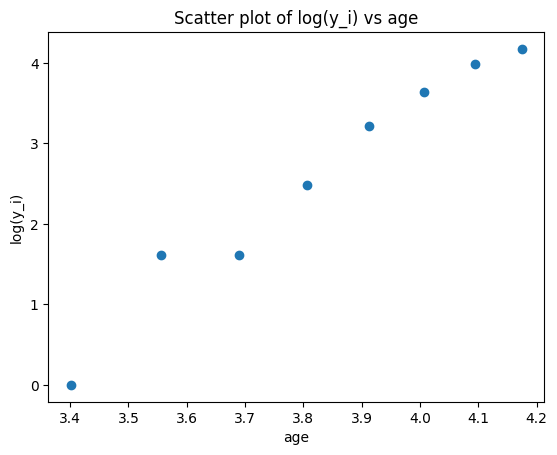

In [5]:
# 散布図
plt.scatter(np.log(df["age"]), df["log_y"])

# ラベルとタイトル
plt.xlabel("age")
plt.ylabel("log(y_i)")
plt.title("Scatter plot of log(y_i) vs age")

plt.show()

In [6]:
X = np.column_stack([np.ones(len(df)), np.log(df["age"])])
# X = np.column_stack([np.ones(len(df)), df["age"]])
y = np.log(df["y_i"]/ df["n_i"])

beta = np.linalg.inv(X.T @ X) @ X.T @ y

df["pred_y_i"] = np.exp(X @ beta) * df["n_i"]
R_sq = 1 - ((df["y_i"] - df["pred_y_i"])**2).sum() / ((df["y_i"] - df["y_i"].mean())**2).sum()

In [7]:
df

,age_group,y_i,n_i,age,log_y,pred_y_i
0,30-34,1,17742,30,0.000000,1.330546
1,35-39,5,16554,35,1.609438,3.204702
2,40-44,5,16059,40,1.609438,7.069199
3,45-49,12,13083,45,2.484907,11.886386
4,50-54,25,10784,50,3.218876,18.733671
5,55-59,38,9645,55,3.637586,30.115732
6,60-64,54,10706,60,3.988984,57.094466
7,65-69,65,9933,65,4.174387,86.677030


In [8]:
R_sq

np.float64(0.8582508509452103)